In [171]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


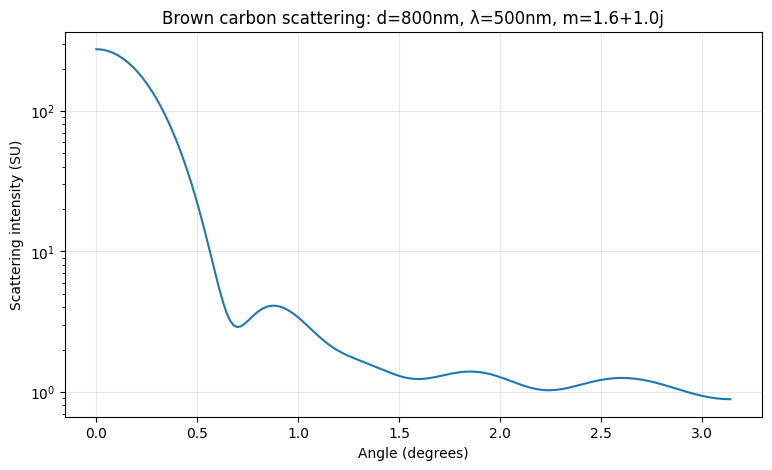

In [172]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [173]:
N_PARTICLES = 500
N_ANGLES = 181
N_SAMPLES = N_PARTICLES * N_ANGLES # total training samples

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 5))     # 5 features: wavelength, diameter, n, k, angle
outputs = np.zeros((N_SAMPLES,))  # single brightness value for every sample input

print(f"Generating {N_PARTICLES} particles, {N_SAMPLES} (particle, angle) training rows through physics")
idx = 0

for i in range(N_PARTICLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550) # these things are probably randomly distributed in order to lower convergence time
    diameter = np.random.uniform(700, 900)
    n = np.random.uniform(1.5, 1.86) # following the paper from Liu et al
    k = np.random.uniform(0.68, 1.00) # following the paper from Liu et al
    m = complex(n, k)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )

    # unfold the pyMieScatt output into ouput points which each have a specific angle value
    for a in range(N_ANGLES):
        inputs[idx] = [n, k, wavelength, diameter, theta[a]]
        outputs[idx] = SU[a]
        idx += 1
    
    
    if i % 100 == 0:
        print(f"  {i}/{N_PARTICLES} particles done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating 500 particles, 90500 (particle, angle) training rows through physics
  0/500 particles done
  100/500 particles done
  200/500 particles done
  300/500 particles done
  400/500 particles done

Done!
Inputs shape: (90500, 5)
Outputs shape: (90500,)


generating sample data

Saved to disk


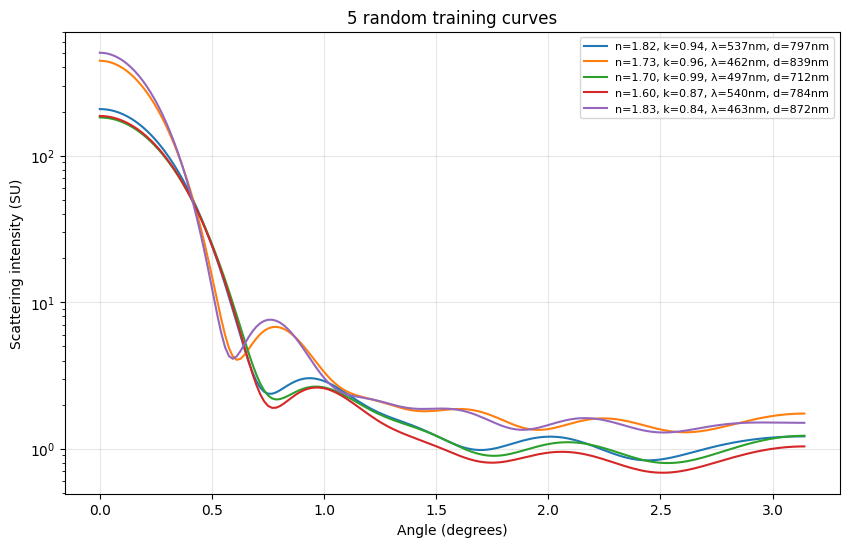

In [174]:
np.save('inputs_5d_10k.npy', inputs) # want to save training data
np.save('outputs_5d_10k.npy', outputs)
print(f"Saved to disk")

plt.figure(figsize=(10, 6))

# Pick 5 random PARTICLES (not rows)
particle_indices = np.random.choice(N_PARTICLES, 5, replace=False)

for p in particle_indices:
    # Get the 181 rows for this particle
    start = p * N_ANGLES
    end = start + N_ANGLES
    
    # Extract the curve and inputs
    curve = outputs[start:end]
    angles = inputs[start:end, 4]   # column 4 is the angle
    

    # Get the particle's other inputs (same for all 181 rows)
    n  = inputs[start, 0]
    k  = inputs[start, 1]
    wl = inputs[start, 2]
    d  = inputs[start, 3]
    
    label = f"n={n:.2f}, k={k:.2f}, λ={wl:.0f}nm, d={d:.0f}nm"
    plt.plot(angles, curve, label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [175]:
# log-transform the outputs
log_outputs = np.log10(outputs+1e-10).reshape(-1,1)   # base-10 log, must reshape into 2d array, since pytorch wants 2d array for math

# normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 1.5) / (1.86 - 1.5)        # n
inputs_norm[:, 1] = (inputs[:, 1] - 0.68) / (1.00 - 0.68)      # k
inputs_norm[:, 2] = (inputs[:, 2] - 450) / 100                  # wavelength
inputs_norm[:, 3] = (inputs[:, 3] - 700) / 200                  # diameter
inputs_norm[:, 4] = inputs[:, 4] / np.pi  
print(inputs_norm)
# train/test split
n_train = int(0.8 * N_SAMPLES)
X_train = torch.FloatTensor(inputs_norm[:n_train])
y_train = torch.FloatTensor(log_outputs[:n_train])
X_test = torch.FloatTensor(inputs_norm[n_train:])
y_test = torch.FloatTensor(log_outputs[n_train:])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

[[0.73199394 0.59865848 0.37454012 0.95071431 0.        ]
 [0.73199394 0.59865848 0.37454012 0.95071431 0.00555556]
 [0.73199394 0.59865848 0.37454012 0.95071431 0.01111111]
 ...
 [0.05705472 0.28218707 0.95661462 0.06895802 0.98888889]
 [0.05705472 0.28218707 0.95661462 0.06895802 0.99444444]
 [0.05705472 0.28218707 0.95661462 0.06895802 1.        ]]
X_train shape: torch.Size([72400, 5])
y_train shape: torch.Size([72400, 1])
X_test shape: torch.Size([18100, 5])
y_test shape: torch.Size([18100, 1])

Sample input (normalized): tensor([0.7320, 0.5987, 0.3745, 0.9507, 0.0000])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [176]:
model = nn.Sequential(
    nn.Linear(5, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 128 to 256
    nn.GELU(),
    nn.Linear(256, 256),
    nn.GELU(),
    nn.Linear(256, 128),    # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(128,1)
    
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=5, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): GELU(approximate='none')
  (8): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 132609


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [177]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [178]:
N_EPOCHS = 200
BATCH_SIZE = 128

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 8000 training data
n_batches = n_train // BATCH_SIZE  # 8000/128

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

import time

training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")


Training: 200 epochs, 565 batches per epoch

Epoch   0  Train Loss: 0.1948690532  Test Loss: 0.0236381758


Epoch  20  Train Loss: 0.0010841843  Test Loss: 0.0010160953
Epoch  40  Train Loss: 0.0002520167  Test Loss: 0.0002201758
Epoch  60  Train Loss: 0.0000600827  Test Loss: 0.0000358510
Epoch  80  Train Loss: 0.0000164895  Test Loss: 0.0000074918
Epoch 100  Train Loss: 0.0000097042  Test Loss: 0.0000311910
Epoch 120  Train Loss: 0.0000087694  Test Loss: 0.0000034106
Epoch 140  Train Loss: 0.0000152461  Test Loss: 0.0000031928
Epoch 160  Train Loss: 0.0000173242  Test Loss: 0.0000027588
Epoch 180  Train Loss: 0.0000111101  Test Loss: 0.0000029033
Total time: 559.90s
Final loss: 4.750019e-06

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


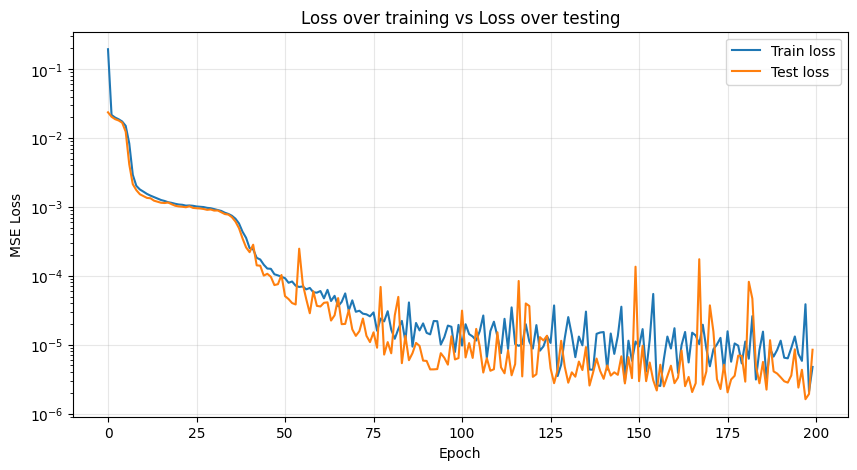

X_train shape: torch.Size([72400, 5])
y_train shape: torch.Size([72400, 1])
y_train min: -0.5165
y_train max: 2.7798
y_train mean: 0.4753
y_train variance: 0.5874

Final train loss: 0.0000
Final test loss: 0.0000


In [179]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min().item():.4f}")
print(f"y_train max: {y_train.max().item():.4f}")
print(f"y_train mean: {y_train.mean().item():.4f}")
print(f"y_train variance: {y_train.var().item():.4f}")
print()
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")

Printing X_test
tensor([[0.2267, 0.3550, 0.1919, 0.3234, 0.0000],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0056],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0111],
        ...,
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9889],
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9944],
        [0.0571, 0.2822, 0.9566, 0.0690, 1.0000]])


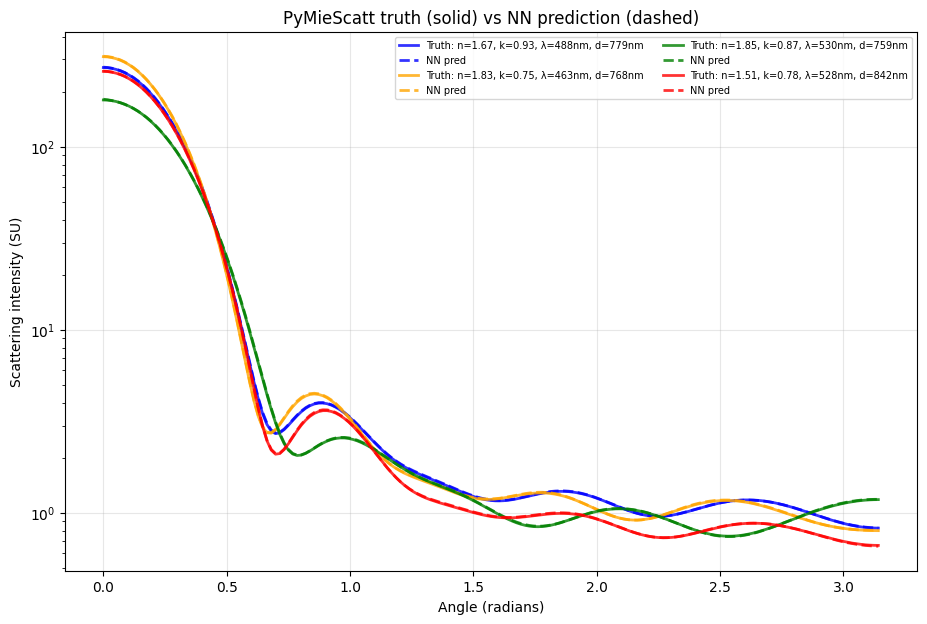

In [180]:
print("Printing X_test")
print(X_test)

# make predictions using the model
with torch.no_grad():
    test_pred = model(X_test)

# number of test particles
n_test_particles = len(X_test) // 181

plt.figure(figsize=(11, 7))
colors = ['blue', 'orange', 'green', 'red']

#pick 4 random particles
particle_indices = np.random.choice(n_test_particles, 4, replace=False)

# plot particles and their angles
for p_idx, color in zip(particle_indices, colors):

    # determing index boundries
    start = p_idx * 181
    end = start + 181
    
    # numpy wanted a 2D array, convert back into 1D for graphing
    true_log_curve = y_test[start:end].numpy().flatten()
    pred_log_curve = test_pred[start:end].numpy().flatten()
    
    true_curve = 10 ** true_log_curve
    pred_curve = 10 ** pred_log_curve
    
    # Un-normalize particle parameters
    n  = X_test[start, 0].item() * (1.86 - 1.5) + 1.5
    k  = X_test[start, 1].item() * (1.00 - 0.68) + 0.68
    wl = X_test[start, 2].item() * 100 + 450
    d  = X_test[start, 3].item() * 200 + 700

    # Un-normalize angles: stored as 0-1, multiply by π for radians
    angles_rad = X_test[start:end, 4].numpy() * np.pi
    angles_deg = np.degrees(angles_rad)   # for display only
    
    label = f"n={n:.2f}, k={k:.2f}, λ={wl:.0f}nm, d={d:.0f}nm"
    plt.plot(angles_rad, true_curve, '-',  color=color, linewidth=2, alpha=0.8, label=f"Truth: {label}")
    plt.plot(angles_rad, pred_curve, '--', color=color, linewidth=2, alpha=0.8, label="NN pred")

plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Total time: 0.06s
[225.05577]
Mean squared error (in log space): 1.042578e+00


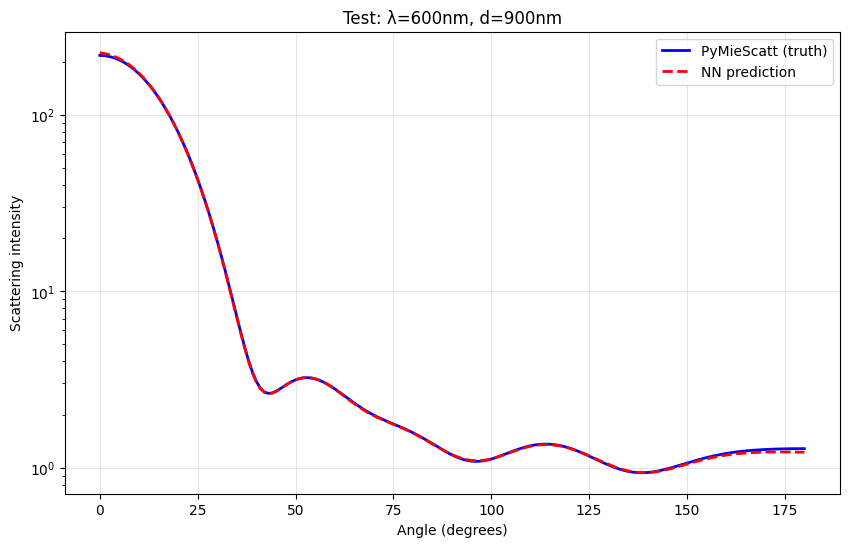

In [181]:

def predict_scattering(n, k, wavelength, diameter, angle):
    """Predict scattering curve for a given wavelength and diameter."""
    # Normalize the inputs the same way we did during training
    norm_wavelength = (wavelength - 450) / 100
    norm_diameter   = (diameter - 700) / 200
    norm_n = (n-1.5)/(1.86-1.5)
    norm_k = (k-0.68)/(0.32)
    norm_a = (angle)/180
    
    # Convert to tensor with shape (1, 2) — one example, two features
    input_tensor = torch.FloatTensor([[norm_n, norm_k, norm_wavelength, norm_diameter, norm_a]])
    
    # Run through the network
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    # Convert from log space back to real brightness
    pred_curve = 10 ** log_pred.numpy().flatten()
    
    return pred_curve


def true_scattering(wavelength, diameter, n, k):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(n, k) # for any set of parameters
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# Pick any wavelength and diameter to test
test_wavelength = 600  # nm
test_diameter = 900    # nm
test_n = 1.9
test_k = 1.0

# Get both predictions
# get prediction curve
nn_curve = [0] * 181

training_start = time.time()

for i in range(181):
    nn_curve[i] = predict_scattering(1.9, 1.0, 600, 900, i)

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(nn_curve[0])
# get true curve
true_curve = true_scattering(test_wavelength, test_diameter, test_n, test_k)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

works well

This section is used to generate some 2d plots. We'll begin by generating the logspaced diameter testing data.

In [182]:
N_D_SPANNING_DATA = 200
m = complex(1.6, 1.0) # match the m value the NN was trained on
fixed_lambda = 500 # I will be varying diameter not wavelength

# Log-spaced diameter sweep — wider than training range
d_span = np.logspace(np.log10(400), np.log10(900), N_D_SPANNING_DATA)

print("Computing Brightness for Each Diamaeter with PyMieScatt")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create array of 181 arrays which have values of 0

# generate the pyMieScatt curve for each diameter value
for i, d in enumerate(d_span):
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, fixed_lambda, d, minAngle=0, maxAngle=180, angularResolution=1
    )

    # add it in it's spot in the array
    truth[i] = SU
    if i % 50 == 0:
        print(f"  {i}/{N_D_SPANNING_DATA}") 
# print(truth)
# === Predictions from NN ===
print("Computing NN sweep...")
nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for k, d in enumerate(d_span):
    norm_w = (fixed_lambda - 450) / 100
    norm_d = (d - 700) / 200
    for i in range(181):
        inp = torch.FloatTensor([[1.6, 1.0, norm_w, norm_d, i/180]])
        with torch.no_grad():
            log_pred = model(inp)
        # must index into the tensor, since the tensor is 2D
        nn_pred[k, i] = 10 ** log_pred[0, 0].numpy()
# print(nn_pred)

print(f"\nDone!")
print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 700 to 900 nm")


Computing Brightness for Each Diamaeter with PyMieScatt
  0/200
  50/200
  100/200
  150/200
Computing NN sweep...

Done!
Diameter range: 400 to 900 nm
Training was: 700 to 900 nm


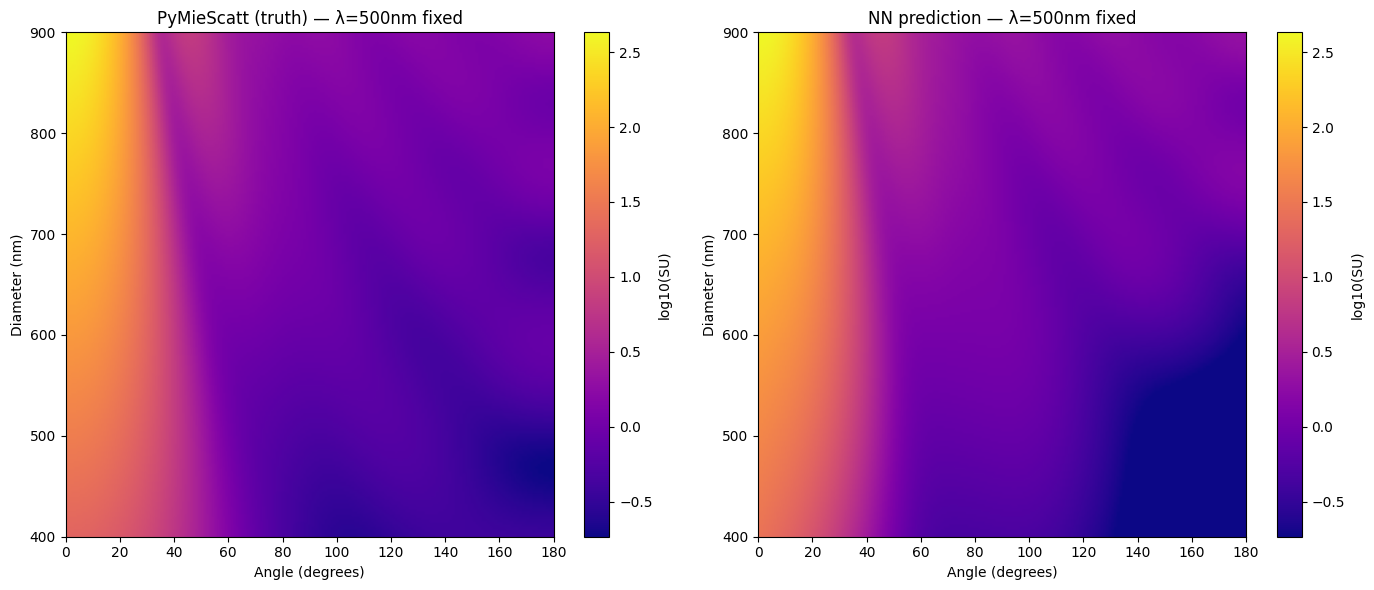

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the same color scale across both plots so they're directly comparable
vmin = np.log10(truth).min()
vmax = np.log10(truth).max()

# === PyMieScatt truth ===
im1 = axes[0].imshow(
    np.log10(truth),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[0].set_title(f"PyMieScatt (truth) — λ={fixed_lambda}nm fixed")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
# Show training range boundaries
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# === NN prediction ===
im2 = axes[1].imshow(
    np.log10(nn_pred),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[1].set_title(f"NN prediction — λ={fixed_lambda}nm fixed")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

plt.tight_layout()
plt.show()

In [184]:
# Test 1: Predictions should vary with input
pred_1 = predict_scattering(1.7, 0.85, 500, 800)
pred_2 = predict_scattering(1.5, 0.7, 480, 750)

print(f"Pred 1 mean: {pred_1.mean():.4f}")
print(f"Pred 2 mean: {pred_2.mean():.4f}")
print(f"Are they different? {not np.allclose(pred_1, pred_2)}")

TypeError: predict_scattering() missing 1 required positional argument: 'angle'